In [1]:
# ============================================================================
# COMPLETE TABTRANSFORMER PIPELINE - FROM DATA LOADING TO MODEL TRAINING
# Each section is a separate cell - copy into your Jupyter notebook
# ============================================================================


"""
================================================================================
CELL 1: Install Required Libraries
================================================================================
"""
!pip install boto3
!pip install pandas
!pip install tensorflow
!pip install scikit-learn

print("✓ All packages installed!")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
✓ All packages installed!


In [2]:
"""
================================================================================
CELL 2: Load Dataset from RunPod S3
================================================================================
"""
import boto3
import pandas as pd
from botocore.config import Config
from io import BytesIO

print("Loading dataset from RunPod S3...")

# ---- RunPod S3 location ----
BUCKET = "e9tcw5eupu"
KEY = "data/eff_training.csv"
ENDPOINT = "https://s3api-eu-ro-1.runpod.io"
REGION = "eu-ro-1"

# ---- Your RunPod S3 credentials ----
ACCESS_KEY = "user_37sKcYrvnk9UXaIY3B3Zr90MH0g"
SECRET_KEY = "rps_YW72UMRXEMRVC8A407OCL08J8G34U1B3QTNO1ETX18pa1n"

cfg = Config(
    region_name=REGION,
    signature_version="s3v4",
    s3={"addressing_style": "path"},
)

s3 = boto3.client(
    "s3",
    aws_access_key_id=ACCESS_KEY,
    aws_secret_access_key=SECRET_KEY,
    endpoint_url=ENDPOINT,
    config=cfg,
)

# Load CSV from RunPod S3 into a variable named `data`
obj = s3.get_object(Bucket=BUCKET, Key=KEY)
data = pd.read_csv(BytesIO(obj["Body"].read()))

print(f"✓ Data loaded successfully!")
print(f"  Data type: {type(data)}")
print(f"  Data shape: {data.shape}")
print(f"\nFirst few rows:")
print(data.head())


Loading dataset from RunPod S3...
✓ Data loaded successfully!
  Data type: <class 'pandas.DataFrame'>
  Data shape: (6134, 5138)

First few rows:
                           photo_id        f1        f2        f3        f4  \
0  6ab1d061f51c6079633aeceed2faeb0b  0.000068  0.108145 -0.138813  0.633156   
1  e94e2e05fb8b099955bbc4fa5ce81e22  0.020843  0.026005 -0.093442  0.736929   
2  ba6951a4f37fc9302243370e927a02e2  0.014542 -0.071332 -0.154407  0.577781   
3  947d16539d4702427aa74f737329ffb9  0.041775  0.075746 -0.128497  0.485010   
4  9326695bf62926ec22690f576a633bba  0.004397  0.058590 -0.154224  0.528140   

         f5        f6        f7        f8        f9  ...         hip  \
0  0.346266 -0.046055  0.016021 -0.058632  0.097968  ...  105.333900   
1  0.240569  0.089982 -0.112391  0.000435 -0.076110  ...  101.478989   
2  0.196485 -0.125341 -0.056713 -0.027295  0.094879  ...   97.488243   
3  0.120409  0.011227  0.017852 -0.089796 -0.011273  ...  120.586845   
4  0.290956 -0.1084

In [3]:
"""
================================================================================
CELL 3: Categorical Encoding for Gender
================================================================================
"""
import pandas as pd

print("Encoding gender feature...")

# Convert 'gender' to categorical and then to numeric codes
data['gender'] = data['gender'].astype('category')
data['gender'] = data['gender'].cat.codes

print(f"✓ Gender encoded!")
print(f"  Unique values: {data['gender'].unique()}")
print(f"  Value counts:\n{data['gender'].value_counts()}")

Encoding gender feature...
✓ Gender encoded!
  Unique values: [0 1]
  Value counts:
gender
1    3650
0    2484
Name: count, dtype: int64


In [4]:
"""
================================================================================
CELL 4: Define Weight Frequencies for Weight_kg Classes
================================================================================
"""
import numpy as np

print("Calculating class weights for weight_kg...")
print(f"Total samples in dataset: {len(data)}")

# Create boolean masks for the three weight_kg classes
class_1_mask = data['weight_kg'] < 60
class_2_mask = data['weight_kg'] > 100
class_3_mask = (data['weight_kg'] >= 60) & (data['weight_kg'] <= 100)

# Calculate class frequencies
freq_class_1 = class_1_mask.sum()
freq_class_2 = class_2_mask.sum()
freq_class_3 = class_3_mask.sum()

print(f"\n✓ Class frequencies:")
print(f"  Class 1 (weight_kg < 60): {freq_class_1}")
print(f"  Class 2 (weight_kg > 100): {freq_class_2}")
print(f"  Class 3 (60 <= weight_kg <= 100): {freq_class_3}")

# Number of classes
num_classes = 3
print(f"\n✓ Number of classes: {num_classes}")

# Compute inverse-frequency weights
total_samples = len(data)

def safe_weight(class_freq):
    if class_freq == 0:
        return np.nan
    return total_samples / (num_classes * class_freq)

weight_class_1 = safe_weight(freq_class_1)
weight_class_2 = safe_weight(freq_class_2)
weight_class_3 = safe_weight(freq_class_3)

print(f"\n✓ Class weights (inverse frequency):")
print(f"  Weight for Class 1 (weight_kg < 60): {weight_class_1:.4f}")
print(f"  Weight for Class 2 (weight_kg > 100): {weight_class_2:.4f}")
print(f"  Weight for Class 3 (60 <= weight_kg <= 100): {weight_class_3:.4f}")


Calculating class weights for weight_kg...
Total samples in dataset: 6134

✓ Class frequencies:
  Class 1 (weight_kg < 60): 1049
  Class 2 (weight_kg > 100): 514
  Class 3 (60 <= weight_kg <= 100): 4571

✓ Number of classes: 3

✓ Class weights (inverse frequency):
  Weight for Class 1 (weight_kg < 60): 1.9492
  Weight for Class 2 (weight_kg > 100): 3.9780
  Weight for Class 3 (60 <= weight_kg <= 100): 0.4473


In [5]:
"""
================================================================================
CELL 5: Define Weight Frequencies for Gender Classes
================================================================================
"""
print("Calculating class weights for gender...")

# Calculate class frequencies for gender
gender_counts = data['gender'].value_counts()

print(f"\n✓ Class frequencies for gender:")
for gender_class, freq in gender_counts.items():
    print(f"  Class {gender_class}: {freq}")

# Number of gender classes
num_gender_classes = len(gender_counts)
print(f"\n✓ Number of gender classes: {num_gender_classes}")

# Compute inverse-frequency weights for each gender class
gender_weights = {}
for gender_class, freq in gender_counts.items():
    gender_weights[gender_class] = safe_weight(freq)

print(f"\n✓ Class weights (inverse frequency) for gender:")
for gender_class, weight in gender_weights.items():
    print(f"  Weight for class {gender_class}: {weight:.4f}")


Calculating class weights for gender...

✓ Class frequencies for gender:
  Class 1: 3650
  Class 0: 2484

✓ Number of gender classes: 2

✓ Class weights (inverse frequency) for gender:
  Weight for class 1: 0.5602
  Weight for class 0: 0.8231


In [6]:
"""
================================================================================
CELL 6: Combine Weight Class and Gender Class Weights
================================================================================
"""
print("Combining weight-class and gender-class weights...")

# Store weight-class weights
weight_class_weights = {
    'weight_<60': weight_class_1,
    'weight_>100': weight_class_2,
    'weight_60_100': weight_class_3
}

print(f"\n✓ Weight-class weights:")
for key, val in weight_class_weights.items():
    print(f"  {key}: {val:.4f}")

print(f"\n✓ Gender-class weights:")
for key, val in gender_weights.items():
    print(f"  Class {key}: {val:.4f}")

# Multiply each gender class with each weight class
combined_weights = {}

print(f"\n✓ Combined weights for each (weight_class, gender_class):")
for w_label, w_w in weight_class_weights.items():
    for g_label, w_g in gender_weights.items():
        wi = w_w * w_g
        combined_weights[(w_label, g_label)] = wi
        print(f"  {w_label} & gender {g_label}: {wi:.4f}")


Combining weight-class and gender-class weights...

✓ Weight-class weights:
  weight_<60: 1.9492
  weight_>100: 3.9780
  weight_60_100: 0.4473

✓ Gender-class weights:
  Class 1: 0.5602
  Class 0: 0.8231

✓ Combined weights for each (weight_class, gender_class):
  weight_<60 & gender 1: 1.0919
  weight_<60 & gender 0: 1.6044
  weight_>100 & gender 1: 2.2284
  weight_>100 & gender 0: 3.2744
  weight_60_100 & gender 1: 0.2506
  weight_60_100 & gender 0: 0.3682


In [7]:
"""
================================================================================
CELL 7: Create Index Column and Weight Dictionary
================================================================================
"""
import pickle

print("Creating index column and weight dictionary...")

# Add index column
data['index'] = range(len(data))

# Move 'index' to the front
cols = ['index'] + [c for c in data.columns if c != 'index']
data = data[cols]

print(f"✓ Index column added!")
print(f"  Columns: {list(data.columns[:5])}...")

# Helper function to get weight class label
def get_weight_class(w):
    if w < 60:
        return 'weight_<60'
    elif w > 100:
        return 'weight_>100'
    else:
        return 'weight_60_100'

# Build final_weights dictionary
final_weights = {}

print(f"\n✓ Building final_weights dictionary...")

for _, row in data.iterrows():
    idx_val = row['index']
    gender_val = row['gender']
    weight_val = row['weight_kg']
    
    w_class = get_weight_class(weight_val)
    w_weight = weight_class_weights[w_class]
    w_gender = gender_weights[gender_val]
    
    combined_w = w_weight * w_gender
    final_weights[idx_val] = combined_w

print(f"✓ Dictionary created with {len(final_weights)} entries")
print(f"  First 5 items: {list(final_weights.items())[:5]}")

# Check index 0
print(f"\n✓ Checking entry with index 0:")
row0 = data.loc[data['index'] == 0].iloc[0]
gender0 = row0['gender']
weight0 = row0['weight_kg']
w_class0 = get_weight_class(weight0)

print(f"  Gender: {gender0}")
print(f"  Weight_kg: {weight0}")
print(f"  Weight class: {w_class0}")
print(f"  Combined weight: {final_weights[0]:.4f}")

# Save final_weights dictionary
print(f"\n✓ Saving final_weights.pkl...")
with open('final_weights.pkl', 'wb') as f:
    pickle.dump(final_weights, f)
print(f"✓ Dictionary saved!")


Creating index column and weight dictionary...
✓ Index column added!
  Columns: ['index', 'photo_id', 'f1', 'f2', 'f3']...

✓ Building final_weights dictionary...


/tmp/ipykernel_2325/2764810991.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['index'] = range(len(data))


✓ Dictionary created with 6134 entries
  First 5 items: [(0, np.float64(0.3681986747807079)), (1, np.float64(0.25057685154939136)), (2, np.float64(0.25057685154939136)), (3, np.float64(0.3681986747807079)), (4, np.float64(0.25057685154939136))]

✓ Checking entry with index 0:
  Gender: 0
  Weight_kg: 72.0
  Weight class: weight_60_100
  Combined weight: 0.3682

✓ Saving final_weights.pkl...
✓ Dictionary saved!


In [8]:
"""
================================================================================
CELL 8: Apply Scaling to Features
================================================================================
"""
import os
import pickle
from sklearn.preprocessing import StandardScaler, RobustScaler

print("Applying scaling to features...")

# Columns to exclude from scaling
exclude_cols = ['photo_id', 'subject_id', 'index', 'gender']

# Standard-scaled feature set
standard_cols = [
    'ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'hip',
    'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh',
    'waist', 'wrist', 'weight_kg', 'height_cm'
]
standard_cols = [c for c in standard_cols if c in data.columns]

# Separate height from other standard features
height_col = "height_cm"
height_cols = [height_col] if height_col in data.columns else []
target_cols = [c for c in standard_cols if c != height_col]

# Robust-scale everything else
robust_cols = [
    c for c in data.columns
    if c not in exclude_cols and c not in target_cols and c not in height_cols
]

print(f"\n✓ Feature groups:")
print(f"  Height features: {len(height_cols)}")
print(f"  Standard features: {len(target_cols)}")
print(f"  Robust features: {len(robust_cols)}")

# Create scalers
height_scaler = StandardScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Fit and transform
if height_cols:
    data[height_cols] = height_scaler.fit_transform(data[height_cols])
    print(f"✓ Height scaled")

if target_cols:
    data[target_cols] = standard_scaler.fit_transform(data[target_cols])
    print(f"✓ Standard features scaled")

if robust_cols:
    data[robust_cols] = robust_scaler.fit_transform(data[robust_cols])
    print(f"✓ Robust features scaled")

# Save scalers
def save_pickle(obj, filename: str):
    path = os.path.join(os.getcwd(), filename)
    with open(path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    return path

if height_cols:
    save_pickle(height_scaler, "scaler_height_cm.pkl")
    print(f"✓ Saved: scaler_height_cm.pkl")

if target_cols:
    save_pickle(standard_scaler, "scaler_standard_features.pkl")
    print(f"✓ Saved: scaler_standard_features.pkl")

if robust_cols:
    save_pickle(robust_scaler, "scaler_robust_features.pkl")
    print(f"✓ Saved: scaler_robust_features.pkl")


Applying scaling to features...

✓ Feature groups:
  Height features: 1
  Standard features: 14
  Robust features: 5120
✓ Height scaled
✓ Standard features scaled
✓ Robust features scaled
✓ Saved: scaler_height_cm.pkl
✓ Saved: scaler_standard_features.pkl
✓ Saved: scaler_robust_features.pkl


In [9]:
"""
CELL 9 (CORRECTED): Split Data into X and Y
"""
print("Splitting data into features (X) and targets (Y)...")

# Target columns (dependent variables) 
target_cols = [
    'ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'hip',
    'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh',
    'waist', 'wrist', 'weight_kg'
]

Y = data[target_cols]
print(f"✓ Target columns: {len(target_cols)}")
print(f"  Y shape: {Y.shape}")

# Drop only IDs and index - KEEP gender and all other features
drop_cols = ['photo_id', 'subject_id', 'index'] + target_cols
X = data.drop(columns=drop_cols)

print(f"✓ Features (X) created")
print(f"  X shape: {X.shape}")
print(f"  'gender' in X: {'gender' in X.columns}")  # Should be True!

Splitting data into features (X) and targets (Y)...
✓ Target columns: 14
  Y shape: (6134, 14)
✓ Features (X) created
  X shape: (6134, 5122)
  'gender' in X: True


In [10]:
"""
================================================================================
CELL 10: Convert Sample Weights Dictionary to Array
================================================================================
"""
print("Converting sample weights to array...")

# Load final_weights.pkl
with open('final_weights.pkl', 'rb') as f:
    final_weights_dict = pickle.load(f)

print(f"✓ Loaded final_weights_dict with {len(final_weights_dict)} entries")

# Build sample_weight array based on DataFrame 'index' column
sample_weights = data['index'].map(final_weights_dict).values.astype('float32')

print(f"✓ Sample weights array created")
print(f"  Shape: {sample_weights.shape}")
print(f"  First 10 weights: {sample_weights[:10]}")


Converting sample weights to array...
✓ Loaded final_weights_dict with 6134 entries
✓ Sample weights array created
  Shape: (6134,)
  First 10 weights: [0.36819866 0.25057685 0.25057685 0.36819866 0.25057685 0.36819866
 0.25057685 0.25057685 0.36819866 0.25057685]


In [11]:
"""
================================================================================
CELL 11: Train/Validation Split
================================================================================
"""
from sklearn.model_selection import train_test_split

print("Splitting into train and validation sets...")

X_train, X_val, Y_train, Y_val, w_train, w_val = train_test_split(
    X, Y, sample_weights,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"✓ Data split complete!")
print(f"\nTraining set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  Y_train shape: {Y_train.shape}")
print(f"  w_train shape: {w_train.shape}")

print(f"\nValidation set:")
print(f"  X_val shape: {X_val.shape}")
print(f"  Y_val shape: {Y_val.shape}")
print(f"  w_val shape: {w_val.shape}")

Splitting into train and validation sets...
✓ Data split complete!

Training set:
  X_train shape: (4907, 5122)
  Y_train shape: (4907, 14)
  w_train shape: (4907,)

Validation set:
  X_val shape: (1227, 5122)
  Y_val shape: (1227, 14)
  w_val shape: (1227,)


In [12]:
"""
================================================================================
CELL 12: Disable GPU (Optional - Use CPU Only)
================================================================================
"""
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

print("✓ GPU disabled - using CPU only")
print("  (Remove this cell if you want to use GPU)")


✓ GPU disabled - using CPU only
  (Remove this cell if you want to use GPU)


In [13]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 228.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 167.6 MB/s eta 0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 2.4.7
    Uninstalling pyparsing-2.4.7:
      Successfully uninstalled pyparsing-2.4.7

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
"""
================================================================================
CELL 13: Import TabTransformer Libraries
================================================================================
"""
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ Libraries imported for TabTransformer")


2026-02-13 10:52:52.602695: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ TensorFlow version: 2.20.0
✓ Libraries imported for TabTransformer


In [15]:
"""
================================================================================
CELL 14: Define Categorical Embedding Layer (Serializable)
================================================================================
"""

@tf.keras.utils.register_keras_serializable()
class CategoricalEmbedding(layers.Layer):
    def __init__(self, num_categories, embedding_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_categories = num_categories
        self.embedding_dim = embedding_dim
        
    def build(self, input_shape):
        self.embedding = layers.Embedding(
            input_dim=self.num_categories,
            output_dim=self.embedding_dim,
            name='categorical_embedding'
        )
        super().build(input_shape)
    
    def call(self, inputs):
        return self.embedding(inputs)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'num_categories': self.num_categories,
            'embedding_dim': self.embedding_dim
        })
        return config

print("✓ CategoricalEmbedding layer defined")

✓ CategoricalEmbedding layer defined


In [16]:
"""
================================================================================
CELL 15: Define Multi-Head Self-Attention Layer (Serializable)
================================================================================
"""

@tf.keras.utils.register_keras_serializable()
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        assert embed_dim % num_heads == 0
        self.projection_dim = embed_dim // num_heads
        
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=self.projection_dim,
            dropout=0.1
        )
        self.layernorm = layers.LayerNormalization(epsilon=1e-6)
        self.add = layers.Add()
        
    def call(self, inputs):
        attention_output = self.attention(query=inputs, key=inputs, value=inputs)
        x = self.add([inputs, attention_output])
        return self.layernorm(x)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads
        })
        return config

print("✓ MultiHeadSelfAttention layer defined")

✓ MultiHeadSelfAttention layer defined


In [17]:
"""
================================================================================
CELL 16: Define Feed-Forward Network Layer (Serializable)
================================================================================
"""

@tf.keras.utils.register_keras_serializable()
class TransformerFFN(layers.Layer):
    def __init__(self, embed_dim, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        
    def build(self, input_shape):
        self.dense1 = layers.Dense(self.ff_dim, activation='relu')
        self.dense2 = layers.Dense(self.embed_dim)
        self.dropout = layers.Dropout(self.dropout_rate)
        self.layernorm = layers.LayerNormalization(epsilon=1e-6)
        self.add = layers.Add()
        super().build(input_shape)
        
    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        x = self.dropout(x, training=training)
        x = self.add([inputs, x])
        return self.layernorm(x)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'ff_dim': self.ff_dim,
            'dropout_rate': self.dropout_rate
        })
        return config

print("✓ TransformerFFN layer defined")

✓ TransformerFFN layer defined


In [18]:
"""
================================================================================
CELL 17: Define Complete Transformer Block (Serializable)
================================================================================
"""

@tf.keras.utils.register_keras_serializable()
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = TransformerFFN(embed_dim, ff_dim, dropout_rate)
        
    def call(self, inputs, training=False):
        x = self.attention(inputs)
        x = self.ffn(x, training=training)
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'dropout_rate': self.dropout_rate
        })
        return config

print("✓ TransformerBlock defined")

✓ TransformerBlock defined


In [19]:
"""
================================================================================
CELL 18: Build TabTransformer Model (Lambda-Free, Serialization Safe)
================================================================================
"""
def build_tabtransformer(
    categorical_features,
    continuous_features,
    num_categories,
    embedding_dim=32,
    num_transformer_blocks=3,
    num_heads=4,
    ff_dim=128,
    mlp_hidden_units=[256, 128],
    dropout_rate=0.1,
    num_outputs=14
):
    print("Building TabTransformer...")
    
    # ===============================
    # INPUTS
    # ===============================
    categorical_input = layers.Input(
        shape=(categorical_features,),
        name='categorical_input'
    )

    continuous_input = layers.Input(
        shape=(continuous_features,),
        name='continuous_input'
    )

    # ===============================
    # CATEGORICAL EMBEDDINGS (NO LAMBDA!)
    # ===============================
    categorical_embeddings = []

    for i in range(categorical_features):
        # Direct tensor slicing (SAFE, no Lambda layer)
        cat_feature = categorical_input[:, i:i+1]

        embedding = CategoricalEmbedding(
            num_categories,
            embedding_dim
        )(cat_feature)  # Shape: (B, 1, D)

        categorical_embeddings.append(embedding)

    # Stack tokens → (B, num_tokens, D)
    if len(categorical_embeddings) > 1:
        x = layers.Concatenate(axis=1)(categorical_embeddings)
    else:
        x = categorical_embeddings[0]  # (B, 1, D)

    # ===============================
    # TRANSFORMER BLOCKS
    # ===============================
    for i in range(num_transformer_blocks):
        x = TransformerBlock(
            embedding_dim,
            num_heads,
            ff_dim,
            dropout_rate
        )(x)
        print(f"  ✓ Transformer block {i+1}")

    # ===============================
    # FLATTEN AFTER TRANSFORMER
    # ===============================
    transformer_output = layers.Flatten()(x)

    # ===============================
    # CONCAT WITH CONTINUOUS FEATURES
    # ===============================
    concatenated = layers.Concatenate()(
        [transformer_output, continuous_input]
    )

    # ===============================
    # MLP HEAD
    # ===============================
    mlp = concatenated
    for i, units in enumerate(mlp_hidden_units):
        mlp = layers.Dense(units, activation='relu')(mlp)
        mlp = layers.BatchNormalization()(mlp)
        mlp = layers.Dropout(dropout_rate)(mlp)
        print(f"  ✓ MLP layer {i+1}: {units} units")

    # ===============================
    # OUTPUT LAYER
    # ===============================
    outputs = layers.Dense(
        num_outputs,
        activation='linear',
        name='output'
    )(mlp)

    # ===============================
    # BUILD MODEL
    # ===============================
    model = Model(
        inputs=[categorical_input, continuous_input],
        outputs=outputs
    )

    print("✓ TabTransformer built successfully!")
    return model

In [20]:
"""
================================================================================
CELL 19: Prepare Data for TabTransformer
================================================================================
"""
print("Preparing data for TabTransformer...")

# Separate features
categorical_cols = ['gender']
continuous_cols = [col for col in X_train.columns if col not in categorical_cols]

print(f"✓ Categorical features: {len(categorical_cols)}")
print(f"✓ Continuous features: {len(continuous_cols)}")

# Extract and convert data types
X_train_cat = X_train[categorical_cols].values.astype('int32')
X_train_cont = X_train[continuous_cols].values.astype('float32')
X_val_cat = X_val[categorical_cols].values.astype('int32')
X_val_cont = X_val[continuous_cols].values.astype('float32')
Y_train_array = Y_train.values.astype('float32')
Y_val_array = Y_val.values.astype('float32')

print(f"\n✓ Data shapes:")
print(f"  Train: cat={X_train_cat.shape}, cont={X_train_cont.shape}, y={Y_train_array.shape}")
print(f"  Val:   cat={X_val_cat.shape}, cont={X_val_cont.shape}, y={Y_val_array.shape}")
print(f"  Weights: train={w_train.shape}, val={w_val.shape}")


Preparing data for TabTransformer...
✓ Categorical features: 1
✓ Continuous features: 5121

✓ Data shapes:
  Train: cat=(4907, 1), cont=(4907, 5121), y=(4907, 14)
  Val:   cat=(1227, 1), cont=(1227, 5121), y=(1227, 14)
  Weights: train=(4907,), val=(1227,)


In [21]:
"""
================================================================================
CELL 20: Manual Grid Search (80/20 Split, No K-Fold)
================================================================================
"""

from itertools import product
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import gc
import time
import numpy as np

print("\n==============================")
print("🚀 Starting Manual Grid Search (80/20 Split)")
print("==============================\n")

# =====================================================
# Create 80/20 split from FULL training data
# =====================================================
X_cat_tr, X_cat_val, X_cont_tr, X_cont_val, Y_tr, Y_val, W_tr, W_val = train_test_split(
    X_train_cat,
    X_train_cont,
    Y_train_array,
    w_train,
    test_size=0.2,
    random_state=42
)

print("✓ Data split complete:")
print(f"  Training samples: {len(X_cat_tr)}")
print(f"  Validation samples: {len(X_cat_val)}")

# Required variables
num_gender_categories = int(X_train['gender'].max()) + 1
NUM_OUTPUTS = Y_train_array.shape[1]

# =====================================================
# Parameter Grid
# =====================================================
param_grid = {
    "embedding_dim": [256, 64, 128],
    "num_transformer_blocks": [6],
    "num_heads": [32, 8, 16],
    "ff_dim": [ 256],
    "mlp_hidden_units": [[256, 128]],
    "dropout_rate": [0.1]
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]

# Remove invalid combos
combinations = [
    p for p in combinations
    if p["embedding_dim"] % p["num_heads"] == 0
]

print(f"\n✅ Total parameter combinations: {len(combinations)}")

best_score = float("inf")
best_params = None

start_time = time.time()

# =====================================================
# Grid Search Loop
# =====================================================
for idx, params in enumerate(combinations):

    print("\n--------------------------------------------------")
    print(f"🔎 Combination {idx+1}/{len(combinations)}")
    print(params)
    print("--------------------------------------------------")

    print("🏗 Building model...")
    model = build_tabtransformer(
        categorical_features=len(categorical_cols),
        continuous_features=len(continuous_cols),
        num_categories=num_gender_categories,
        embedding_dim=params["embedding_dim"],
        num_transformer_blocks=params["num_transformer_blocks"],
        num_heads=params["num_heads"],
        ff_dim=params["ff_dim"],
        mlp_hidden_units=params["mlp_hidden_units"],
        dropout_rate=params["dropout_rate"],
        num_outputs=NUM_OUTPUTS
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )

    print("🏋 Training...")

    history = model.fit(
        [X_cat_tr, X_cont_tr],
        Y_tr,
        validation_data=([X_cat_val, X_cont_val], Y_val),
        sample_weight=W_tr,
        epochs=200,
        batch_size=64,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    val_loss = min(history.history["val_loss"])
    print(f"📊 Validation Loss: {val_loss:.6f}")

    if val_loss < best_score:
        best_score = val_loss
        best_params = params
        print("⭐ NEW BEST MODEL FOUND!")

    tf.keras.backend.clear_session()
    gc.collect()

    elapsed = (time.time() - start_time) / 60
    print(f"⏱ Elapsed Time: {elapsed:.2f} minutes")

print("\n=================================")
print("🏆 GRID SEARCH COMPLETE")
print("=================================")
print(f"Best Parameters: {best_params}")
print(f"Best Validation Loss: {best_score:.6f}")


🚀 Starting Manual Grid Search (80/20 Split)

✓ Data split complete:
  Training samples: 3925
  Validation samples: 982

✅ Total parameter combinations: 9

--------------------------------------------------
🔎 Combination 1/9
{'embedding_dim': 256, 'num_transformer_blocks': 6, 'num_heads': 32, 'ff_dim': 256, 'mlp_hidden_units': [256, 128], 'dropout_rate': 0.1}
--------------------------------------------------
🏗 Building model...
Building TabTransformer...


2026-02-13 10:52:56.975376: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


  ✓ Transformer block 1
  ✓ Transformer block 2
  ✓ Transformer block 3
  ✓ Transformer block 4
  ✓ Transformer block 5
  ✓ Transformer block 6
  ✓ MLP layer 1: 256 units
  ✓ MLP layer 2: 128 units
✓ TabTransformer built successfully!
🏋 Training...
Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.7785 - mae: 0.8176 - val_loss: 1.5540 - val_mae: 0.9920 - learning_rate: 0.0010
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.4197 - mae: 0.6443 - val_loss: 0.6954 - val_mae: 0.6541 - learning_rate: 0.0010
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.3435 - mae: 0.5933 - val_loss: 0.4672 - val_mae: 0.5304 - learning_rate: 0.0010
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 0.2917 - mae: 0.5530 - val_loss: 0.4169 - val_mae: 0.5004 - learning_rate: 0.0010
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.2572 - mae: 0.5259 - val_loss: 0.3365 - val_mae: 0.4479 - learning_rate: 0.0010
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 

/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


  ✓ Transformer block 1
  ✓ Transformer block 2
  ✓ Transformer block 3
  ✓ Transformer block 4
  ✓ Transformer block 5
  ✓ Transformer block 6
  ✓ MLP layer 1: 256 units
  ✓ MLP layer 2: 128 units
✓ TabTransformer built successfully!
🏋 Training...
Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - loss: 0.8089 - mae: 0.8175 - val_loss: 1.9197 - val_mae: 1.0936 - learning_rate: 0.0010
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.4109 - mae: 0.6349 - val_loss: 0.7191 - val_mae: 0.6685 - learning_rate: 0.0010
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.3410 - mae: 0.5947 - val_loss: 0.4698 - val_mae: 0.5331 - learning_rate: 0.0010
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.2954 - mae: 0.5602 - val_loss: 0.4072 - val_mae: 0.4939 - learning_rate: 0.0010
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.2656 - mae: 0.5375 - val_loss: 0.3476 - val_mae: 0.4557 - learning_rate: 0.0010
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 

/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 16, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


  ✓ Transformer block 2
  ✓ Transformer block 3
  ✓ Transformer block 4
  ✓ Transformer block 5
  ✓ Transformer block 6
  ✓ MLP layer 1: 256 units
  ✓ MLP layer 2: 128 units
✓ TabTransformer built successfully!
🏋 Training...
Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - loss: 0.7966 - mae: 0.8217 - val_loss: 1.8754 - val_mae: 1.0846 - learning_rate: 0.0010
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 0.4167 - mae: 0.6382 - val_loss: 0.7072 - val_mae: 0.6567 - learning_rate: 0.0010
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 0.3416 - mae: 0.5920 - val_loss: 0.4551 - val_mae: 0.5222 - learning_rate: 0.0010
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.3017 - mae: 0.5588 - val_loss: 0.3938 - val_mae: 0.4835 - learning_rate: 0.0010
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 0.2583 - mae: 0.5245 - val_loss: 0.3541 - val_mae: 0.4583 - learning_rate: 0.0010
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss

In [22]:
"""
================================================================================
CELL 21: Train Final Best Model on FULL Training Data
================================================================================
"""

print("\n==============================")
print("🚀 Training Final Best Model")
print("==============================\n")

if best_params is None:
    raise ValueError("❌ Run Grid Search first!")

print("🏆 Best Parameters:")
print(best_params)

final_model = build_tabtransformer(
    categorical_features=len(categorical_cols),
    continuous_features=len(continuous_cols),
    num_categories=num_gender_categories,
    embedding_dim=best_params["embedding_dim"],
    num_transformer_blocks=best_params["num_transformer_blocks"],
    num_heads=best_params["num_heads"],
    ff_dim=best_params["ff_dim"],
    mlp_hidden_units=best_params["mlp_hidden_units"],
    dropout_rate=best_params["dropout_rate"],
    num_outputs=NUM_OUTPUTS
)

final_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

history = final_model.fit(
    [X_train_cat, X_train_cont],
    Y_train_array,
    validation_data=([X_val_cat, X_val_cont], Y_val_array),
    sample_weight=w_train,
    epochs=200,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=1
)

print("✅ Final model training complete.")


🚀 Training Final Best Model

🏆 Best Parameters:
{'embedding_dim': 256, 'num_transformer_blocks': 6, 'num_heads': 16, 'ff_dim': 256, 'mlp_hidden_units': [256, 128], 'dropout_rate': 0.1}
Building TabTransformer...
  ✓ Transformer block 1
  ✓ Transformer block 2
  ✓ Transformer block 3
  ✓ Transformer block 4
  ✓ Transformer block 5
  ✓ Transformer block 6
  ✓ MLP layer 1: 256 units
  ✓ MLP layer 2: 128 units
✓ TabTransformer built successfully!
Epoch 1/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.7024 - mae: 0.7871 - val_loss: 1.2875 - val_mae: 0.8988 - learning_rate: 0.0010
Epoch 2/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - loss: 0.3866 - mae: 0.6220 - val_loss: 0.5871 - val_mae: 0.5984 - learning_rate: 0.0010
Epoch 3/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 0.3191 - mae: 0.5725 - val_loss: 0.3865 - val_mae: 0.4798 - learning_rate: 0.0010
Epoch 4/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.2735 - mae: 0.5372 - val_loss: 0.3645 - val_mae: 0.4621 - lear

In [23]:
"""
================================================================================
CELL 22: Save Final Model
================================================================================
"""

print("💾 Saving model as tabtransformerBest.h5 ...")
final_model.save("tabtransformerBest-v17.h5")
print("✅ Model saved successfully!")

💾 Saving model as tabtransformerBest.h5 ...
✅ Model saved successfully!


In [24]:
"""
================================================================================
CELL 22: Save Final Model (Keras Format)
================================================================================
"""

print("💾 Saving model as tabtransformerBest.keras ...")

final_model.save("tabtransformerBest-v17.keras")

print("✅ Model saved successfully!")
print("📁 File created: tabtransformerBest.keras")

💾 Saving model as tabtransformerBest.keras ...
✅ Model saved successfully!
📁 File created: tabtransformerBest.keras


📊 Plotting training history...


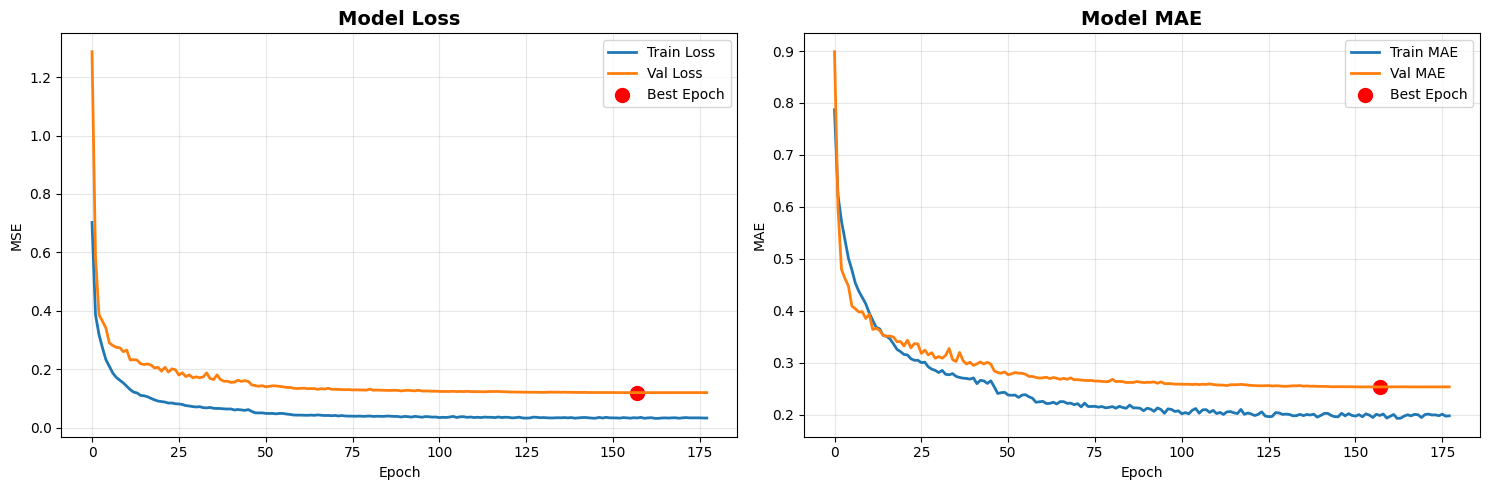


✓ Training Summary:
  Total epochs trained: 178
  Best epoch: 158
  Best train loss: 0.0329
  Best val loss: 0.1194
  Best train MAE: 0.1982
  Best val MAE: 0.2532


In [25]:
"""
================================================================================
CELL 23: Plot Training History (Updated for EarlyStopping)
================================================================================
"""

print("📊 Plotting training history...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ===============================
# Loss Plot
# ===============================
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)

best_epoch = np.argmin(history.history['val_loss'])

axes[0].scatter(
    best_epoch,
    history.history['val_loss'][best_epoch],
    color='red',
    s=100,
    label='Best Epoch'
)

axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ===============================
# MAE Plot
# ===============================
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)

axes[1].scatter(
    best_epoch,
    history.history['val_mae'][best_epoch],
    color='red',
    s=100,
    label='Best Epoch'
)

axes[1].set_title('Model MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# ===============================
# Print Metrics
# ===============================
print("\n✓ Training Summary:")
print(f"  Total epochs trained: {len(history.history['loss'])}")
print(f"  Best epoch: {best_epoch + 1}")
print(f"  Best train loss: {history.history['loss'][best_epoch]:.4f}")
print(f"  Best val loss: {history.history['val_loss'][best_epoch]:.4f}")
print(f"  Best train MAE: {history.history['mae'][best_epoch]:.4f}")
print(f"  Best val MAE: {history.history['val_mae'][best_epoch]:.4f}")

In [26]:
"""
================================================================================
CELL 24: Evaluate Final Best Model on Validation Set
================================================================================
"""

print("🔍 Evaluating final best model...")

# Safety check
if 'final_model' not in globals():
    raise ValueError("❌ final_model not found. Run Cell 21 first.")

val_loss, val_mae = final_model.evaluate(
    [X_val_cat, X_val_cont],
    Y_val_array,
    batch_size=64,
    verbose=1
)

print(f"\n✓ Validation metrics:")
print(f"  Loss (MSE): {val_loss:.4f}")
print(f"  MAE: {val_mae:.4f}")

# ===============================
# Predictions
# ===============================
print("\n📈 Generating predictions...")

predictions = final_model.predict(
    [X_val_cat, X_val_cont],
    batch_size=64
)

# ===============================
# Per-target MAE
# ===============================
print("\n✓ Per-target MAE:")

target_names = Y_train.columns.tolist()

for i, name in enumerate(target_names):
    mae = np.mean(np.abs(predictions[:, i] - Y_val_array[:, i]))
    print(f"  {name:25s}: {mae:.4f}")

print("\n✅ Evaluation complete!")

🔍 Evaluating final best model...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1194 - mae: 0.2532

✓ Validation metrics:
  Loss (MSE): 0.1194
  MAE: 0.2532

📈 Generating predictions...


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (64, 16, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

✓ Per-target MAE:
  ankle                    : 0.3022
  arm-length               : 0.2625
  bicep                    : 0.2496
  calf                     : 0.2934
  chest                    : 0.2209
  forearm                  : 0.2609
  hip                      : 0.2339
  leg-length               : 0.2763
  shoulder-breadth         : 0.2402
  shoulder-to-crotch       : 0.2214
  thigh                    : 0.2591
  waist                    : 0.2091
  wrist                    : 0.3093
  weight_kg                : 0.2064

✅ Evaluation complete!
